In [ ]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report

In [ ]:
file_path = '/content/BrEaST-Lesions-USG-clinical-data-Dec-15-2023.xlsx'
data=pd.read_excel(file_path)


In [ ]:
data.head()

,CaseID,Image_filename,Mask_tumor_filename,Mask_other_filename,Pixel_size,Age,Tissue_composition,Signs,Symptoms,Shape,...,Echogenicity,Posterior_features,Halo,Calcifications,Skin_thickening,Interpretation,BIRADS,Verification,Diagnosis,Classification
0,1,case001.png,case001_tumor.png,NaN,0.007812,57,heterogeneous: predominantly fat,breast scar,family history of breast/ovarian cancer,irregular,...,heterogeneous,shadowing,no,no,yes,Breast scar (surgery)&Breast scar (radiotherapy),2,confirmed by follow-up care,not applicable,benign
1,2,case002.png,case002_tumor.png,NaN,0.006462,not available,homogeneous: fat,not available,not available,oval,...,hypoechoic,no,no,no,no,Dysplasia&Fibroadenoma,4b,confirmed by biopsy,Intramammary lymph node,benign
2,3,case003.png,case003_tumor.png,NaN,0.006944,56,heterogeneous: predominantly fat,no,nipple discharge,oval,...,hyperechoic,no,no,no,no,Duct filled with thick fluid&Intraductal papil...,4a,confirmed by biopsy,Usual ductal hyperplasia (UDH)&Pseudoangiomato...,benign
3,4,case004.png,case004_tumor.png,NaN,0.007812,43,homogeneous: fibroglandular,no,no,round,...,hypoechoic,no,no,no,no,Cyst filled with thick fluid,3,confirmed by follow-up care,not applicable,benign
4,5,case005.png,case005_tumor.png,NaN,0.007812,67,homogeneous: fat,nipple retraction&palpable,family history of breast/ovarian cancer,oval,...,complex cystic/solid,enhancement,no,no,no,Suspicion of malignancy&Intraductal papilloma,4b,confirmed by biopsy,Encapsulated papillary carcinoma&Ductal carcin...,malignant


In [ ]:
data=data.drop(columns=['CaseID', 'Image_filename', 'Image_filename', 'Mask_tumor_filename',
                        'Mask_other_filename', 'Pixel_size'])


In [ ]:
data = data[data['Classification'] != 'normal']

In [ ]:
data= data.replace('not available', np.nan)

<ipython-input-7-eeadd1cab77c>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data= data.replace('not available', np.nan)


In [ ]:
numerical_columns=data.select_dtypes(include=['float64', 'int32']).columns
categorical_columns= data.select_dtypes(include=['object']).columns

In [ ]:
for col in numerical_columns:
    data[col]=data[col].fillna(data[col].mean())

In [ ]:
data[categorical_columns] = data[categorical_columns].replace(['Missing', 'not applicable', 'not available'] , 'Unknown')
data[categorical_columns] = data[categorical_columns].fillna('Unknown')

In [ ]:
numerical_columns

Index(['Age'], dtype='object')

In [ ]:
categorical_columns

Index(['Tissue_composition', 'Signs', 'Symptoms', 'Shape', 'Margin',
       'Echogenicity', 'Posterior_features', 'Halo', 'Calcifications',
       'Skin_thickening', 'Interpretation', 'BIRADS', 'Verification',
       'Diagnosis', 'Classification'],
      dtype='object')

In [ ]:
for col in categorical_columns:
    data[col]=data[col].astype(str)

In [ ]:
from sklearn.preprocessing import LabelEncoder


# Encode categorical data
label_encoders = {}  # Dictionary to store LabelEncoders for each categorical column
for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le  # Store the encoder for later use

# At this stage, all categorical columns are encoded as numerical values.


In [ ]:
# Define the target column
target_column = 'Classification'  # Update this with the actual target column name if it's different

# Separate features (X) and labels (y)
X = data.drop(columns=[target_column])  # All columns except the target column
y = data[target_column]  # The target column

# Display shapes for verification
print("Features shape:", X.shape)
print("Labels shape:", y.shape)


Features shape: (252, 15)
Labels shape: (252,)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardize numerical columns
scaler = StandardScaler()
X[numerical_columns] = scaler.fit_transform(X[numerical_columns])

# Now all numerical features are scaled to have a mean of 0 and standard deviation of 1.


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Check the size of the training and testing sets
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (176, 15)
Testing set size: (76, 15)



Training and evaluating: Logistic Regression
Accuracy: 0.87
Precision: 0.89
Recall: 0.87
F1 Score: 0.87


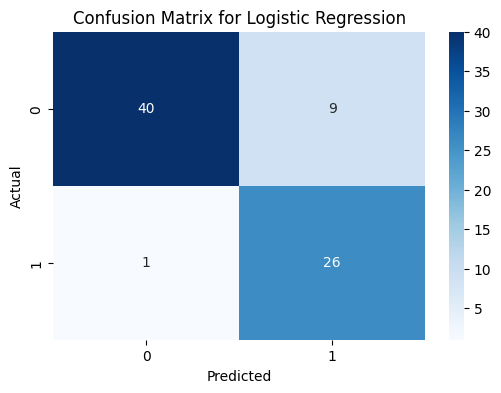


Training and evaluating: K-Nearest Neighbors
Accuracy: 0.79
Precision: 0.85
Recall: 0.79
F1 Score: 0.79


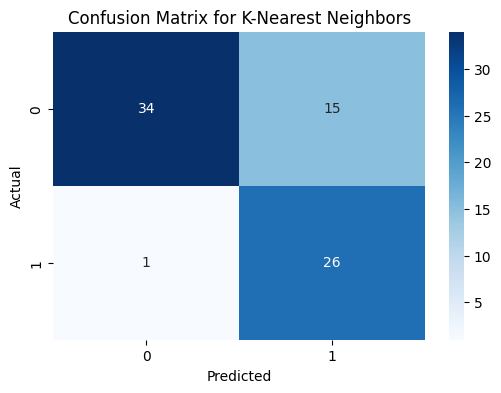


Training and evaluating: Support Vector Machine
Accuracy: 0.82
Precision: 0.86
Recall: 0.82
F1 Score: 0.82


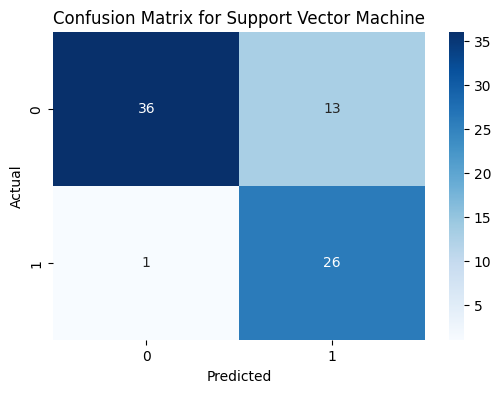

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Change the Hyperparameters to improve the performance
models = {
    "Logistic Regression": LogisticRegression(max_iter=400, solver='liblinear', C=3.0),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=38, metric='minkowski', p=1),
    "Support Vector Machine": SVC(kernel='linear', C=0.01)
}

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining and evaluating: {name}")

    # Train the model
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Display metrics
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1:.2f}")

    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f"Confusion Matrix for {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Top Features by Importance (Linear SVM):
               Feature  Importance
12              BIRADS    1.486666
7   Posterior_features    0.972645
0                  Age    0.846909
10     Skin_thickening    0.739328
9       Calcifications    0.458409


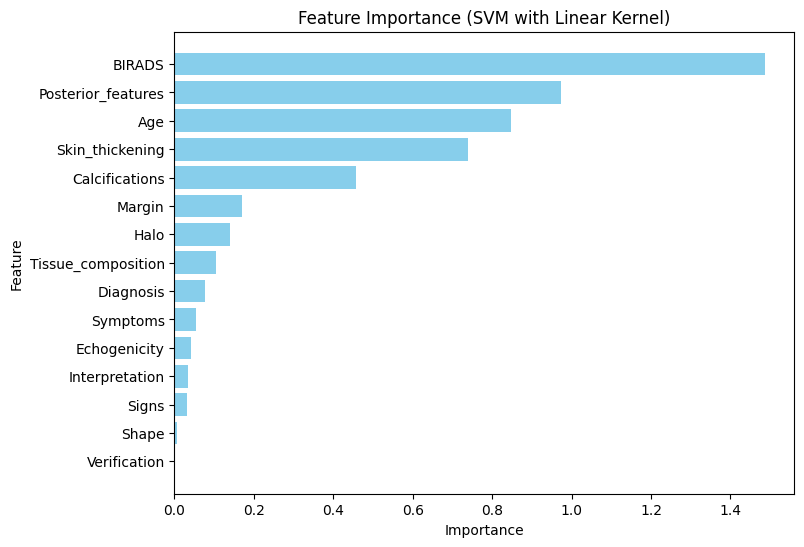

In [ ]:
# Train SVM model with a linear kernel
svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_train, y_train)

# Extract feature importance (coefficients)
feature_importance = np.abs(svm_linear.coef_[0])
feature_names = X.columns

# Combine feature names and importance into a DataFrame
importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

# Display the top features
print("Top Features by Importance (Linear SVM):")
print(importances_df.head())

# Visualize feature importance
plt.figure(figsize=(8, 6))
plt.barh(importances_df['Feature'], importances_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Feature Importance (SVM with Linear Kernel)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()



Training and evaluating: Decision Tree
Accuracy: 0.94
Precision: 0.94
Recall: 0.94
F1 Score: 0.94


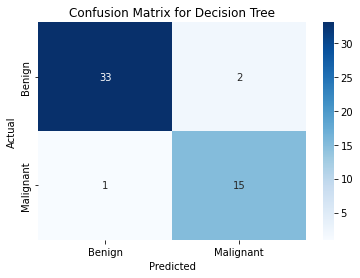

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Change the hyperparamters
decision_tree = DecisionTreeClassifier(
    random_state=42,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1
)

# Train the Decision Tree
print("\nTraining and evaluating: Decision Tree")
decision_tree.fit(X_train, y_train)

# Predict on the test set
y_pred_dt = decision_tree.predict(X_test)

# Calculate metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, average='weighted')
recall_dt = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

# Display metrics
print(f"Accuracy: {accuracy_dt:.2f}")
print(f"Precision: {precision_dt:.2f}")
print(f"Recall: {recall_dt:.2f}")
print(f"F1 Score: {f1_dt:.2f}")

# Generate confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title("Confusion Matrix for Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



Training and evaluating: Random Forest
Accuracy: 0.94
Precision: 0.95
Recall: 0.94
F1 Score: 0.94


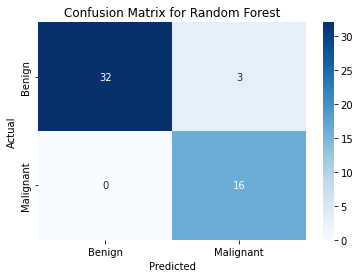

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest Classifier
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1
)

# Train the Random Forest
print("\nTraining and evaluating: Random Forest")
random_forest.fit #write your code here

# Predict on the test set
y_pred_rf = random_forest.predict(X_test)

# Calculate metrics
accuracy_rf = #write your code here
precision_rf = #write your code here
recall_rf = #write your code here
f1_rf = #write your code here

# Display metrics
print(f"Accuracy: {accuracy_rf:.2f}")
print(f"Precision: {precision_rf:.2f}")
print(f"Recall: {recall_rf:.2f}")
print(f"F1 Score: {f1_rf:.2f}")

# Generate confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title("Confusion Matrix for Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
